# **ESERCIZIO 6.1**


**OBIETTIVI**

In questo esercizio devo studiare il modello di Ising 1D usando sia Metrpolis sia Gibbs, confrontando i risultati numerici con la soluzione analitica. In particolare, è richiesto il confronto tra dati teorici e simulati delle seguenti grandezze: energia totale, calore specifico, suscettività e magnetizzazione.

In particolare, devo fare simulazioni per temperature diverse, tra 0.5 e 2.0, calcolando U, C, $\chi$, M, per ogni temperatura, sia con Metropolis sia con Gibbs, per entrambi i casi:

1) **CAMPO NULLO (h=0):** in questo caso devo calcolare l'energia interna, il calore specifico e la suscettività.
2) **CAMPO ESTERNO (h=0.02):** in questo caso devo calcolare la magnetizzazione.


**MODELLO DI ISING**

Il modello di Ising è un modello matematico utilizzato per descrivere il comportamento di un magnete. Questo modello stabilisce che il magnetismo di un materiale è determinato dai momenti di dipolo magnetico di diversi spin atomici (che possono assumere solo configurazione up (associata a +1) o down (-1)) disposti su un reticolo.

Il comportamento del sistema è determinato dalla sua energia totale, che dipende sia dall'interazione di scambio, che descrive le interazioni degli spin con i loro primi vicini, sia dalla presenza di un campo magnetico esterno, che porta gli spin del materiale ad allinearsi.

**IMPLEMENTAZIONE ALGORITMO DI METROPOLIS**

L'algoritmo di Metropolis è una tecnica di campionamento utilizzata per generare una sequenza di punti distribuiti secondo una specifica densità di probabilità $p(x)$. Questo algoritmo è molto versatile in quanto può campionare essenzialmente qualunque funzione in qualsiasi dimensione, come ad esempio il peso di Boltzmann $p(\mu) = \frac{e^{-\beta H_\mu}}{Z}$ (dove $H_\mu$ è l'hamiltoniano dello stato $\mu$), e soprattutto non richiede di conoscere la funzione di partizione $Z = \sum_{\{\nu\}} e^{-\beta H_\nu}$ associata, che agisce come costante di normalizzazione e che spesso è difficile da calcolare.

L'algoritmo ha alla base la costruzione di una catena di Markov i cui passi sono selezionati affinché la distribuzione dei punti campionati, dopo un numero sufficientemente grande di passi, sia esattamente la $p(x)$ desiderata, ovvero $P(x_n=x)\rightarrow p(x)$ per $n\rightarrow\infty$.

Questo risultato si ottiene imponendo la condizione del bilancio dettagliato, che garantisce che, all’equilibrio, il flusso di probabilità "in uscita" da uno stato sia compensato da un flusso uguale "in entrata". Matematicamente, la formula è: $p(\mu) K(\nu|\mu) = p(\nu) K(\mu|\nu)$, dove $p(\mu)$ è la probabilità di trovarsi nello stato $\mu$ (secondo la distribuzione di Boltzmann) mentre $K(\nu|\mu)$ è la probabilità totale di transizione dallo stato $\mu$ allo stato $\nu$. In particolare, l'algoritmo di Metropolis scompone la probabilità K in due componenti:
-  Probabilità di proposta ($T$): la probabilità di scegliere di cambiare uno spin (mossa trial).
-  Probabilità di accettazione ($A$): la probabilità di confermare effettivamente quel cambiamento.

Sostituendo queste definizioni nella condizione del bilancio dettagliato e riordinando i termini, si ottiene quindi un'espressione che non dipende dalla normalizzazione:
$$\frac{A(\nu|\mu)}{A(\mu|\nu)} = \frac{T(\mu|\nu) p(\nu)}{T(\nu|\mu) p(\mu)}$$

Per quanto riguarda l'implementazione, l'algoritmo di Metropolis costruisce una catena di Markov attraverso diversi step:
- INIZIALIZZAZIONE: si scelgono una temperatura e uno stato iniziale $\mu$ (ad esempio, spin tutti allineati per $T=0$).
- PROPOSTA DI UNA MOSSA: si genera un nuovo stato di prova $\nu$. Nel modello di Ising, si sceglie casualmente uno spin $k$ e si propone di invertirlo
- CALCOLO DELLA VARIAZIONE DI ENERGIA: si calcola la differenza $E_\nu - E_\mu$. Nel modello di Ising, questo calcolo coinvolge solo lo spin scelto e i suoi vicini primi.
- ACCETTAZIONE O RIFIUTO DELLA MOSSA:
    - se $\Delta E < 0$ la mossa abbassa l'energia, quindi viene sempre accettata
    - se $\Delta E > 0$, la mossa viene accettata con probabilità $A(\nu|\mu) = \exp(-\beta \Delta E)$.
    - Ovvero: si estrae un numero casuale $r$ tra $0$ e $1$. Se $r < A(\nu|\mu)$, si ribalta lo spin; altrimenti, il sistema rimane nello stato precedente.

Infine, è fondamentale prevedere un periodo di riequilibrazione iniziale, dal momento che la catena di Markov parte da una posizione iniziale arbitraria: i primi passi non seguono ancora la distribuzione target, che si raggiunge solo asintoticamente, e quindi devono essere scartati.

**IMPLEMENTAZIONE ALGORITMO DI GIBBS**

L'algoritmo di Gibbs si basa sulla probabilità condizionata che uno spin $s_k$ assuma il valore +1 o −1 dati i valori dei suoi vicini.
  $$p(s_k' = \pm 1 \mid \{s_j\}_{j \neq k})
= \frac{1}{1 + \exp\left(\mp 2\beta \left(J \sum_{\langle i,k\rangle} s_i + H\right)\right)}$$

Per implementare questa formula nel codice, devo calcolare:
  -  $\beta = \frac{1}{T}$: l'inverso della temperatura
  -  $J$: la costante di accoppiamento, che va impostata a 1
  -  somma sui vicini $\sum s_i = s_{k-1} + s_{k+1}$:  poiché il modello è 1D, ogni spin k ha solo due primi vicini, ovvero $s_{k−1}$ e $s_{k+1}$
    Nel campionamento di Gibbs uso direttamente la probabilità scritta sopra per assegnare il nuovo valore dello spin. Quindi:
1) All'interno della funzione *move* per il caso Gibbs (*sim_type == 3*): calcolo la probabilità p di avere lo spin +1 usando i valori dei vicini *_particle(this->pbc(i-1)).getspin()* e *_particle(this->pbc(i+1)).getspin()*.
2) Genero un numero casuale tra [0,1).
3) Se r<p, imposto lo spin a +1, altrimenti lo imposto a -1.
  Notare che nella formula della probabilità di Gibbs non compare il valor medio di H ma H, quindi nel codice non devo usare U ma *_H*.

**IMPLEMENTAZIONE GRANDEZZE**

Inoltre, devo aggiornare il codice, implementando le formule per il calcolo delle grandezze sopra citate, ricordando che il codice calcola già l'energia interna $U(N,T) = \langle H \rangle$. Devo quindi aggiungere, in measure:

1. $U(N,T) = \langle H \rangle_{h=0}$
2. $\chi(N,T) = \beta \langle (\sum_{i=1,N}s_i)^2 \rangle_{h=0}$
3. $M(N,T,h=0.02)= \langle \sum_{i=1,N}s_i \rangle_{h=0.02}$

Per il calore specifico,

4. $C(N,T) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h=0}^2)$
   
invece, il procedimento è più delicato, in quanto come si può notare dalla formula dipende dalla fluttuazione dell'energia $\langle H^2 \rangle - \langle H \rangle^2$.

Per questo motivo, in measure_cv() salvo solamente il quadrato dell'energia per particella U/N, e poi eseguo tutte le altre operazioni in averages(). In particolare, in averages c'è un altro punto delicato, che riguarda cosa viene salvato in global_averages(). A tal proposito, ritengo utile commentare le due righe seguenti:

    _global_av(_index_cv)+=cv_block-e2;
    _global_av2(_index_cv)+=pow(cv_block,2)-e2*e2;

Per far sì che global_av e global_av2 contenessero le informazioni di mio interesse per eseguire il data blocking, ovvero rispettivamente cv_block e cv_block^2, ho dovuto sottrarre rispettivamente e2 e e2* e2. Infatti, in global_av(index_cv) è già memorizzata la quantità e2, per come è definito global_av(); allo stesso modo, global_av2(index_cv) contiene invece e2*e2.

Infatti:
    
    _block_av += _measurement; (in questo caso measurement contiene il quadrato dell'energia per particella)
    _average     = _block_av / double(_nsteps);
    _global_av  += _average;
    _global_av2 += _average % _average;
    

**RIEQUILIBRAZIONE DEL SISTEMA**

Per prima cosa, devo procedere con la riequilibrazione del sistema prima della raccolta delle misure. Infatti, la configurazione iniziale letta dal file non rappresenta in generale uno stato dell’equilibrio termodinamico alla temperatura di 0.5 che ho imposto nell'input. Se iniziassi subito con le misure, non avrei la certezza che quelle misure siano prese quando il sistema è già in equilibrio, condizione necessaria per avere i risultati di interesse. Per questo motivo ho modificato il codice in modo che, prima di ogni acquisizione dati, il sistema compia un'evoluzione "a vuoto", ovvero compie solo degli step, per 20000 passi senza effettuare alcuna misura. In questo modo mi assicuro che il mio sistema abbia raggiunto le condizioni di equilibrio termodinamico.

**SIMULAZIONI**

Dopo aver equilibrato il sistema, procedo con la simulazione vera e propria: in particolare, per ciascuno dei 4 casi (Metropolis e Gibbs ciascuno con h=0 e h=0.02) ho avviato una simulazione da 20 blocchi, ognuno da 20000 step. Per quanto riguarda le proprietà misurate, dovevo calcolare la magnetizzazione, l'energia totale, il calore specifico e la suscettività.


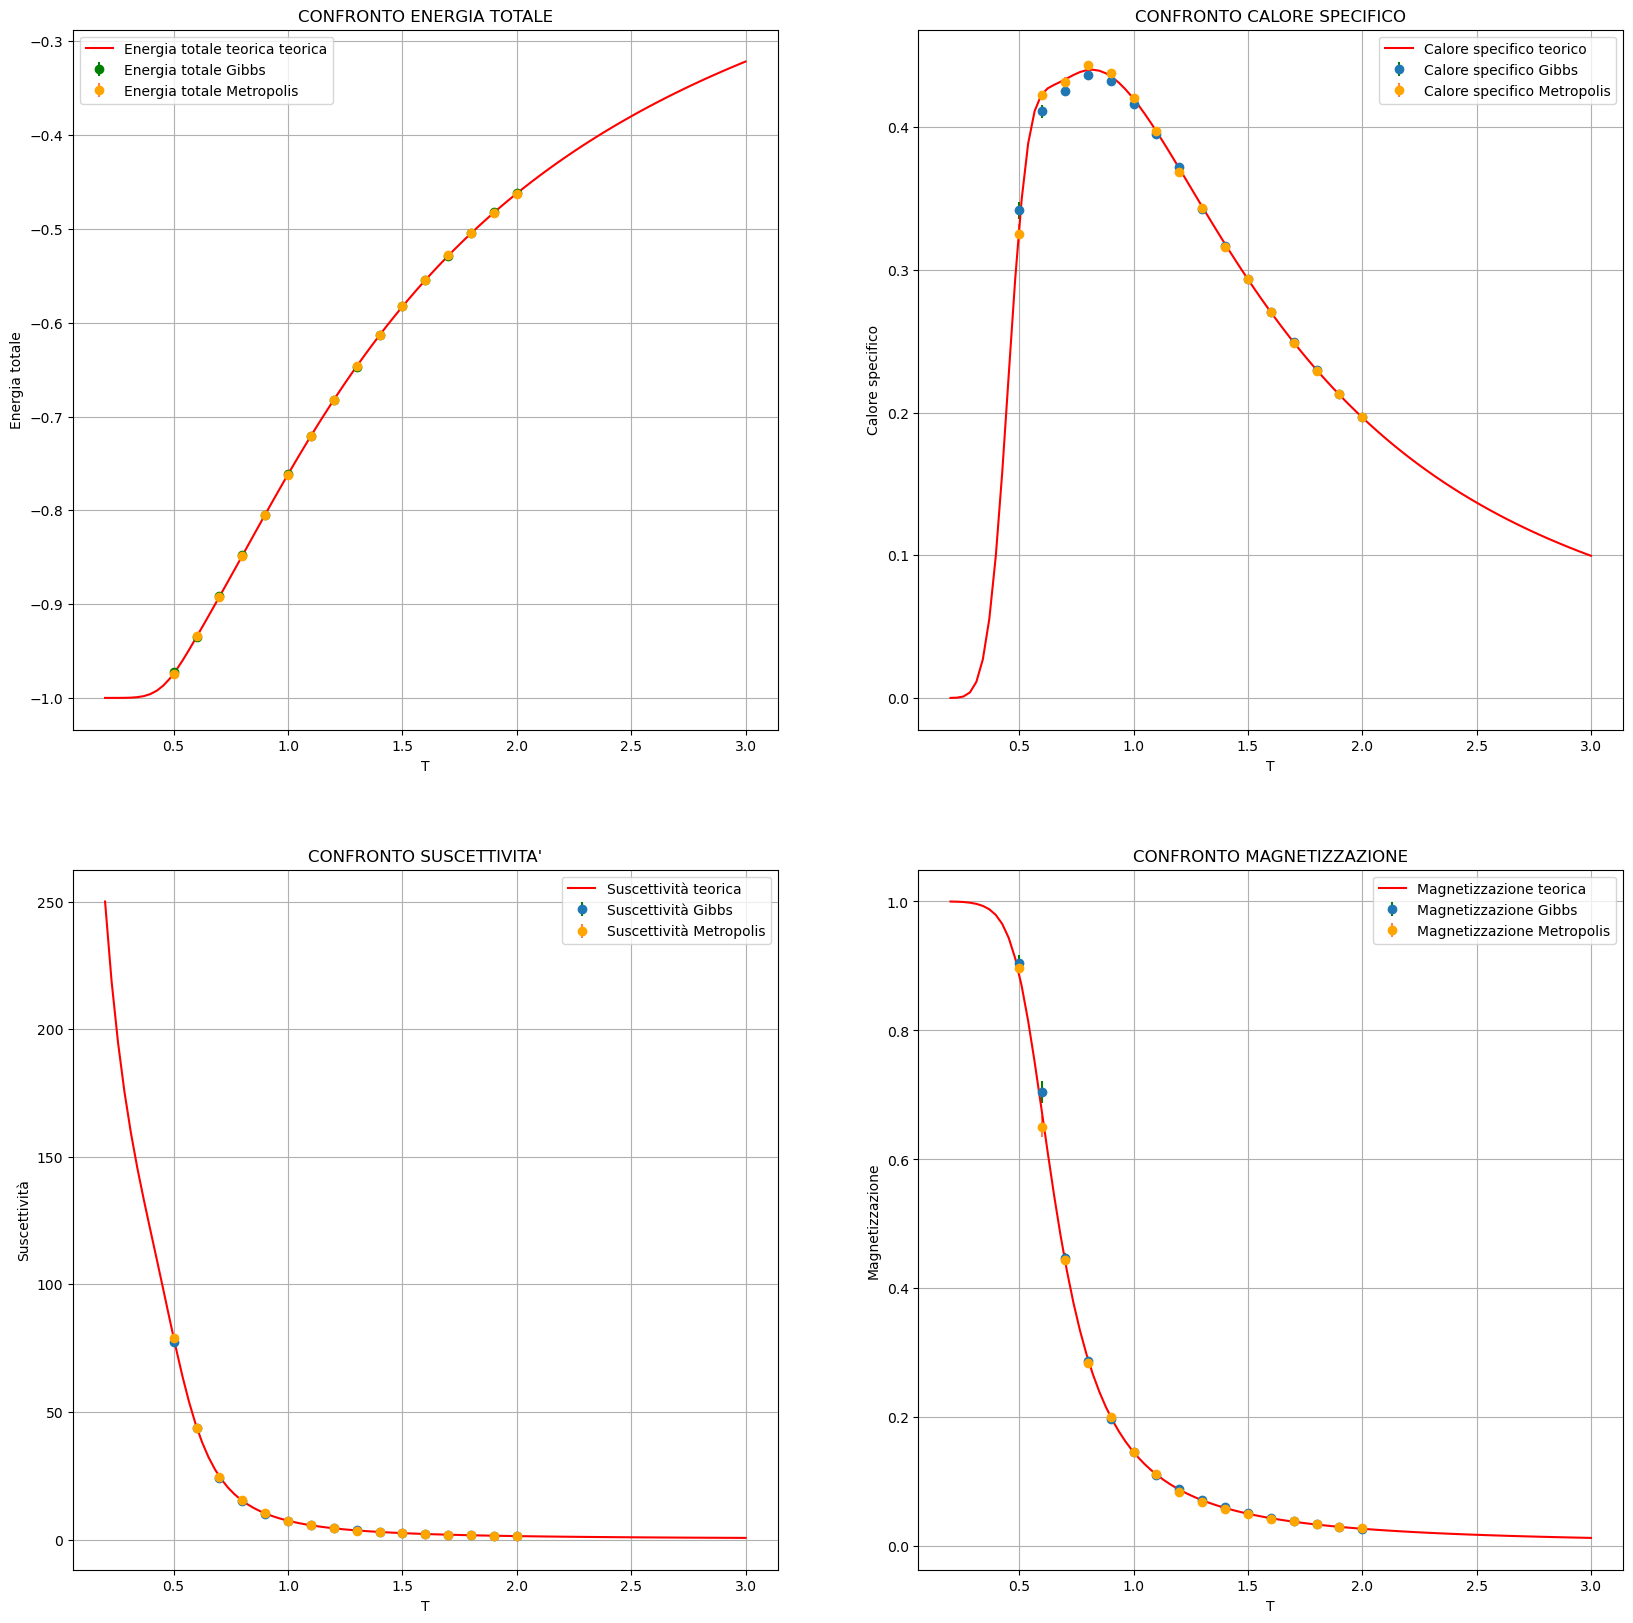

In [1]:
import numpy as np
import matplotlib.pyplot as plt

########################################################################################################
#ENERGIA POTENZIALE

#carico i dati per metropolis e per gibbs
U_0_Gibbs=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/total_energy_Gibbs_0.dat")
U_0_Metro=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/total_energy_0.dat")

#seleziono la colonna della temperatura
T=U_0_Gibbs[:,0]

media_U_Gibbs=U_0_Gibbs[:,2]
media_U_Metro=U_0_Metro[:,2]

errore_U_Gibbs=U_0_Gibbs[:,3]
errore_U_Metro=U_0_Metro[:,3]
########################################################################################################
#CALORE SPECIFICO
C_0_Gibbs=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/cv_Gibbs_0.dat")
C_0_Metro=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/cv_0.dat")

media_C_Gibbs=C_0_Gibbs[:,2]
media_C_Metro=C_0_Metro[:,2]

errore_C_Gibbs=C_0_Gibbs[:,3]
errore_C_Metro=C_0_Metro[:,3]
########################################################################################################
#SUSCETTIVITA'
Chi_Gibbs=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/chi_Gibbs_0.dat")
Chi_Metro=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/chi_0.dat")

media_Chi_Gibbs=Chi_Gibbs[:,2]
media_Chi_Metro=Chi_Metro[:,2]

errore_Chi_Gibbs=Chi_Gibbs[:,3]
errore_Chi_Metro=Chi_Metro[:,3]
########################################################################################################
#MAGNETIZZAZIONE
M_Gibbs=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/magnet_Gibbs.dat")
M_Metro=np.loadtxt("NSL_SIMULATOR_6.1/OUTPUT/magnet.dat")

media_M_Gibbs=M_Gibbs[:,2]
media_M_Metro=M_Metro[:,2]

errore_M_Gibbs=M_Gibbs[:,3]
errore_M_Metro=M_Metro[:,3]


#####CURVE TEORICHE
points=100
T_th = np.linspace(0.2,3.0,num=points) #genero le temperature a cui valutare le curve teoriche: genero 100 valori da 0.2 a 3
beta = 1/T_th #calcolo beta
J = 1.0 #costante di accoppiamento ferromagnetico
Ns = 50 #numero di spin della catena
th = np.tanh(J/T_th) #tan(beta*J)
thN= th**Ns #tan(beta*J)^Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN ) #energia per spin

heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)  #calcolo calore specifico

h=0.02 #external field
b = 1/T_th

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)) #autovalori
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns  #funzione di partizione
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)  #magnetizzazione

X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN) #suscettività




plt.figure(figsize=(20,20))

plt.subplot(2,2,1)
plt.errorbar(T, media_U_Gibbs, errore_U_Gibbs, fmt='o', color='green', label="Energia totale Gibbs")
plt.errorbar(T,media_U_Metro, errore_U_Metro,fmt='o', color="orange", ecolor='coral', label="Energia totale Metropolis")
plt.plot(T_th, e, color="red", label="Energia totale teorica teorica")
plt.title("CONFRONTO ENERGIA TOTALE")
plt.xlabel("T")
plt.ylabel("Energia totale")
plt.legend()
plt.grid(True)

plt.subplot(2,2,2)
plt.errorbar(T, media_C_Gibbs, errore_C_Gibbs,fmt='o', ecolor='green', label="Calore specifico Gibbs")
plt.errorbar(T,media_C_Metro, errore_C_Metro,fmt='o', color="orange", ecolor='coral', label="Calore specifico Metropolis")
plt.plot(T_th, heat, color="red", label="Calore specifico teorico")
plt.title("CONFRONTO CALORE SPECIFICO")
plt.xlabel("T")
plt.ylabel("Calore specifico")
plt.legend()
plt.grid(True)

plt.subplot(2,2,3)
plt.errorbar(T, media_Chi_Gibbs, errore_Chi_Gibbs,fmt='o',  ecolor='green', label="Suscettività Gibbs")
plt.errorbar(T,media_Chi_Metro, errore_Chi_Metro,fmt='o', color="orange", ecolor='coral', label="Suscettività Metropolis")
plt.plot(T_th, X, color="red", label="Suscettività teorica")
plt.title("CONFRONTO SUSCETTIVITA'")
plt.xlabel("T")
plt.ylabel("Suscettività")
plt.legend()
plt.grid(True)

plt.subplot(2,2,4)
plt.errorbar(T, media_M_Gibbs, errore_M_Gibbs, fmt='o', ecolor='green', label="Magnetizzazione Gibbs")
plt.errorbar(T,media_M_Metro, errore_M_Metro,fmt='o', color="orange", ecolor='coral', label="Magnetizzazione Metropolis")
plt.plot(T_th, M, color="red", label="Magnetizzazione teorica")
plt.title("CONFRONTO MAGNETIZZAZIONE")
plt.xlabel("T")
plt.ylabel("Magnetizzazione")
plt.legend()
plt.grid(True)
plt.show()

**CONFRONTO DATI**

Qualitativamente possiamo osservare come i dati simulati riproducano abbastanza fedelmente i risultati attesi. Questo dimostra che entrambi gli algoritmi di Metropolis e Gibbs seguono l'andamento delle curve teoriche per tutte le grandezze termodinamiche (U, C, $\chi$, M), risultato che conferma la corretta implementazione del campionamento stattistico di entrambi i simulatori e la corretta implementazione dei pesi di Boltzmann.

Per verificare quantitativamente l’attendibilità dei risultati ottenuti confronto il valore medio ottenuto dalle diverse simulazioni con il corrispondente valore teorico, calcolo lo scarto e valuto quante deviazioni standard separano il dato simulato dalla previsione teorica. Se la differenza cade entro due o tre sigma, il risultato è verosimilmente compatibile con la teoria entro le fluttuazioni statistiche, mentre scarti sistematicamente maggiori potrebbero indicare problemi di mancata equilibrazione.

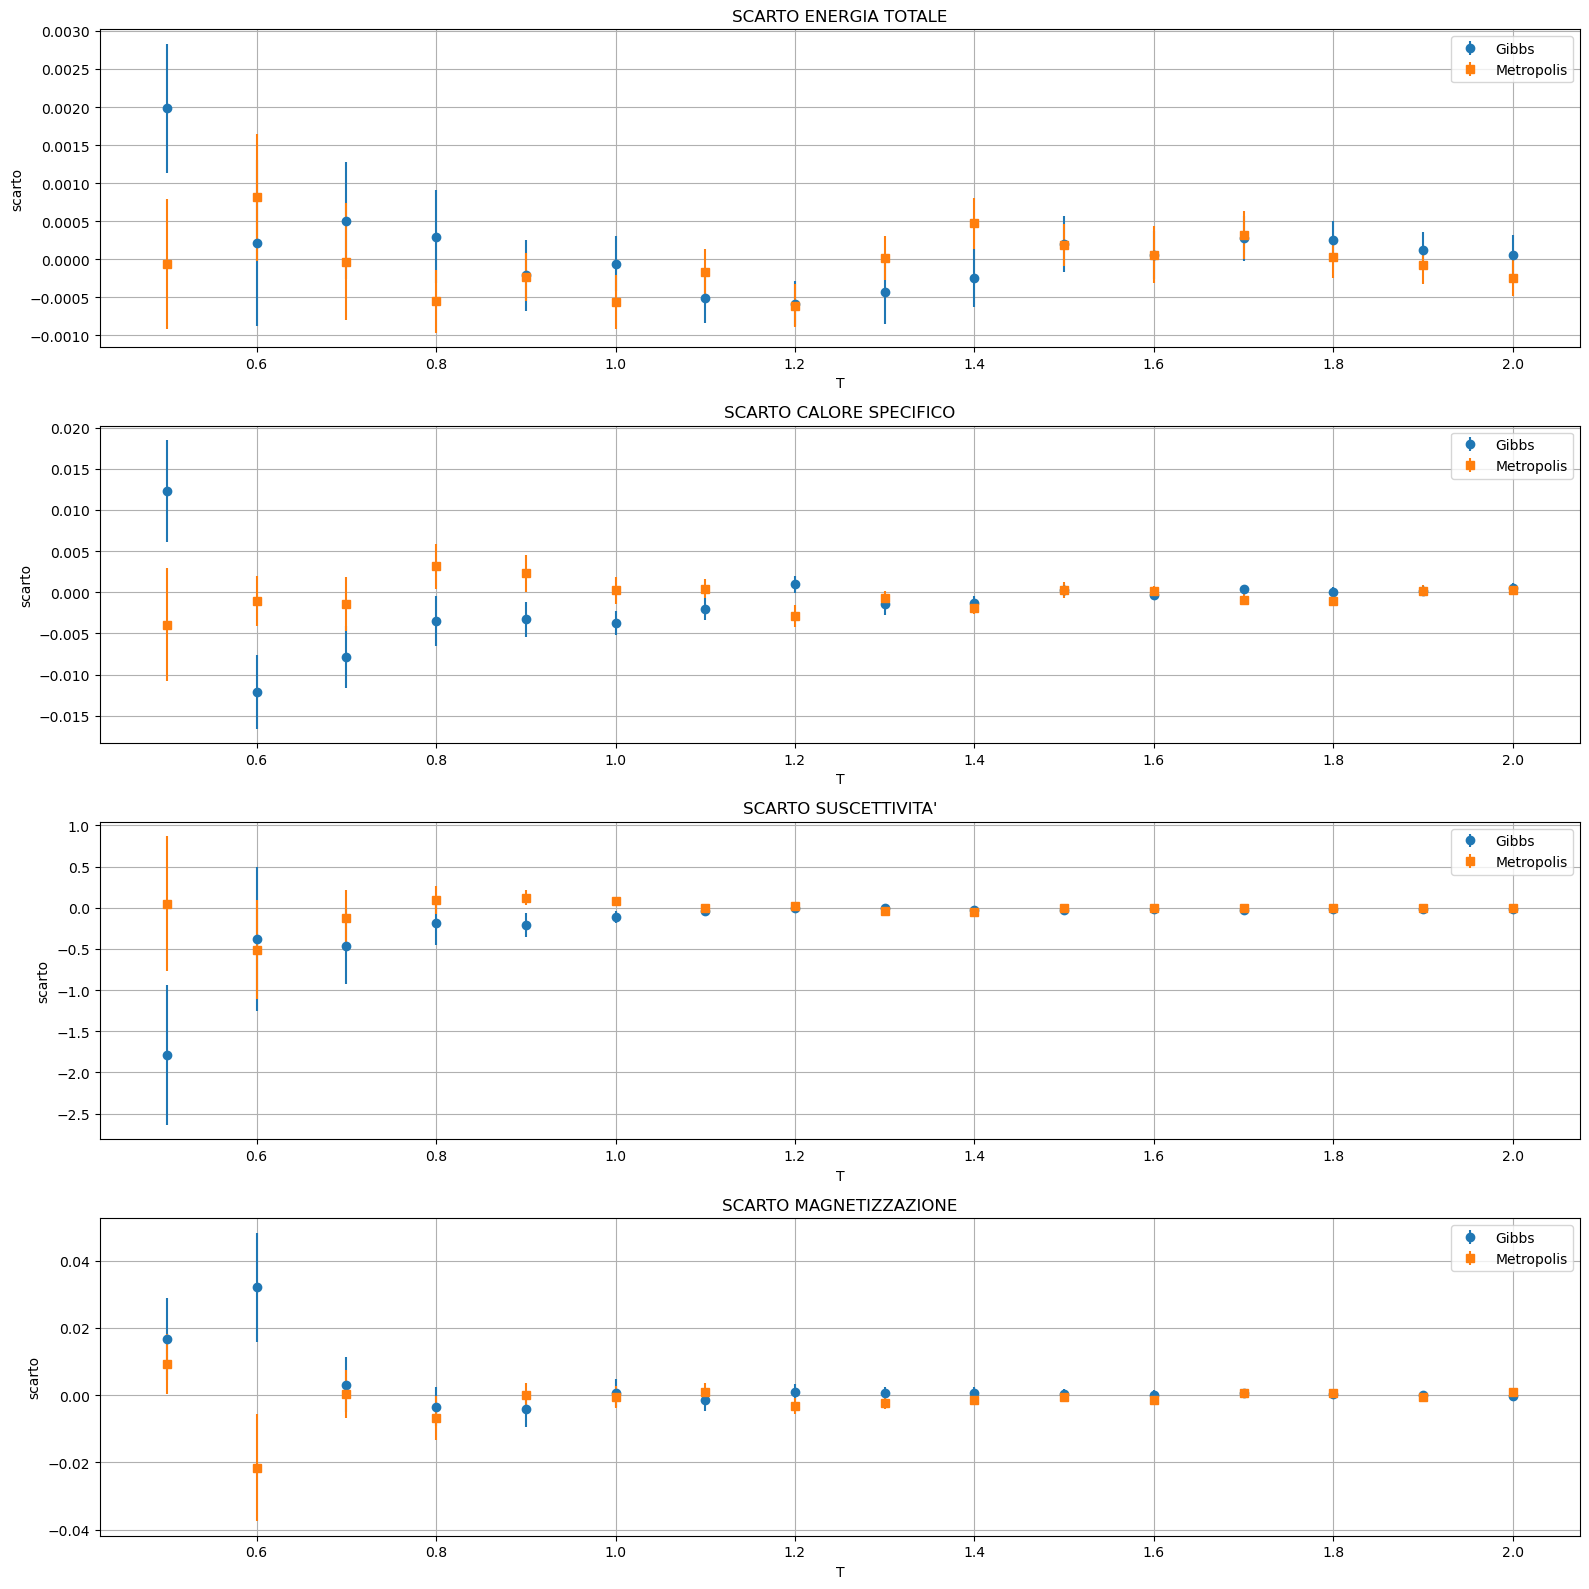

In [2]:
T_th=T
points=100
beta = 1/T_th
J = 1.0
Ns = 50
th = np.tanh(J/T_th)
thN= th**Ns
ch = 1/th
e = -J*( th + ch*thN )/( 1 + thN )

heat=((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)

h=0.02 #external field
b = 1/T_th

l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
Z = l1**Ns + l2**Ns
M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
        + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)

X = beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

# scarto
plt.figure(figsize=(16,16))

#total energy
plt.subplot(4,1,1)
plt.errorbar(T, media_U_Gibbs-e, errore_U_Gibbs, fmt='o', label='Gibbs')       # errore unitario sugli scarti
plt.errorbar(T, media_U_Metro-e, errore_U_Metro, fmt='s', label='Metropolis')
plt.title("SCARTO ENERGIA TOTALE")
plt.xlabel("T")
plt.ylabel("scarto")
plt.legend()
plt.grid(True)

#calore specifico
plt.subplot(4,1,2)
plt.errorbar(T, media_C_Gibbs-heat, errore_C_Gibbs, fmt='o', label='Gibbs')
plt.errorbar(T, media_C_Metro-heat, errore_C_Metro, fmt='s', label='Metropolis')
plt.title("SCARTO CALORE SPECIFICO")
plt.xlabel("T")
plt.ylabel("scarto")
plt.legend()
plt.grid(True)

#Suscettività
plt.subplot(4,1,3)
plt.errorbar(T, media_Chi_Gibbs-X, errore_Chi_Gibbs, fmt='o', label='Gibbs')
plt.errorbar(T, media_Chi_Metro-X, errore_Chi_Metro, fmt='s', label='Metropolis')
plt.title("SCARTO SUSCETTIVITA'")
plt.xlabel("T")
plt.ylabel("scarto")
plt.legend()
plt.grid(True)

#Magnetizzazione
plt.subplot(4,1,4)
plt.errorbar(T, media_M_Gibbs-M, errore_M_Gibbs, fmt='o', label='Gibbs')
plt.errorbar(T, media_M_Metro-M, errore_M_Metro, fmt='s', label='Metropolis')
plt.title("SCARTO MAGNETIZZAZIONE")
plt.xlabel("T")
plt.ylabel("scarto")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**ANALISI RISULTATI OTTENUTI**

Dai grafici dello scarto tra valore atteso e valore misurato delle varie grandezze emerge l'accordo tra dati simulati e dati attesi: analizzando i punti simulati con le rispettive incertezze, infatti, possiamo constatare come la differenza con il valore atteso rientri sicuramente entro tre sigma.

In particolare, alcuni punti dei grafici risultano essere molto diversi (a volte addirittura incompatibili) tra simulazione Metropolis e simulazione Gibbs, come per esempio il primo punto dell'energia totale e della suscettività, i primi due del calore specifico, e il secondo punto della magnetizzazione. Questi punti segnalano quindi delle criticità a basse temperature. Verosimilmente, questa criticità potrebbe essere dovuta al fatto che a basse temperature è necessario un tempo maggiore per raggiungere il regime di equilibrio termodinamico: nella mia simulazione, infatti, ho usato lo stesso numero di passi (20000) per equilibrare il sistema ad ogni temperatura; probabilmente, avrei dovuto dedicare più passi all'equilibrazione dei primi valori di temperatura analizzati.

Inoltre, è interessante osservare come la suscettività mostri delle incertezze sensibilmente più elevate rispetto alle altre grandezze, e in particolare rispetto all'energia totale per particella: infatti, la suscettività è legata alla varianza della magnetizzazione, che fluttua maggiormente rispetto all'energia interna, portando a incertezze più elevate.